# Tutorial 5: Comparing a Circuit Model to a Full-Wave Simulation

Circuit-level models used in **simpleLOMs** can reliably reproduce what a full-wave EM solver actually gives you.

In FEM simulations, a **Touchstone** file (eg. `.s2p`) is generated containing the S-parameters of a device for a range of frequencies. This tutorial shows you how to run comparisons of circuit-level models to touchstone models using a touchstone file generated using HFSS. 

In this tutorial you will learn how to 

1. read the Touchstone reference with `scikit-rf`,
2. draw the device with the `schematics` feature (this requires knowledge of what geometry you simulated)
3. build the distributed circuit-level model using CPWs, and fit the **Optimized** lumped model,
4. overlay all three responses and quantify the residual,
5. repeat the identical comparison across a catalog of five HFSS exports spanning
   weak to very strong coupling, symmetric and asymmetric.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

import simpleLOMs as sl

sl.apply_style()


The reference file `results/cpw_7mm_hfss.s2p` was exported from HFSS for a
**7 mm CPW resonator** with a **50 fF** coupling capacitor at each end
($C_\mathrm{tog}=0$), driven through **two 50 Ω ports**. We first need to give `simpleLOMs` these same parameters, so the FEM curve and the circuit model describe the same device.


In [3]:
# Device parameters
cpw  = sl.CPWParams(ep_r=11.45)          # ultracold silicon
d    = 7e-3                           # 7 mm resonator line
Cc   = 50e-15                         # 0.05 pF coupler on each port
Ctog = 0.0                            # no line-to-ground capacitance


## 1. Read the Touchstone reference

`simpleLOMs` is built on `scikit-rf` which reads the `.s2p` into a `Network` object, which is the same object that `simpleLOMs` circuit models use. We take the frequency
grid from the file itself, so every model below is evaluated on the same
points as the FEM data.


In [4]:
ref  = rf.Network("results/cpw_7mm_hfss.s2p")     # <-- your FEM / measured file
freq = ref.frequency                              # reuse the file's frequency grid
f    = freq.f / 1e9                               # GHz, for plotting

print("loaded:", ref)
print("frequency: {:.3f} - {:.3f} GHz, {} points".format(f[0], f[-1], len(f)))


loaded: 2-Port Network: 'cpw_7mm_hfss',  3.95-11.85 GHz, 401 pts, z0=[50.+0.j 50.+0.j]
frequency: 3.950 - 11.850 GHz, 401 points


## 2. (Optional) Draw the device

It is important to confirm that the device that you will simulate at the circuit level reflects the actual FEM output.

To do this, use   `schematics` to  generate a diagram with the device parameters we already passed to `CPWParams`
labelled. This is the circuit topology we are comparing against the FEM export.

for this specific system, the topology is: `P1 — Cc — CPW — Cc — P2`


In [5]:
from pathlib import Path
figdir = Path("figures")
figdir.mkdir(exist_ok=True)

sch = sl.cpw_schematic_2port(
    d, Cc, Cc, Ctog, Ctog,
    cpw_params=cpw, freq=freq, Z0=50,
    annotations={"length_mm": d * 1e3, "Cc_fF": Cc * 1e15, "Ctog_fF": Ctog * 1e15},
)

# (optional) save the schematic as a vector graphic and interactive HTML.
sch.save_svg(figdir / "cpw_7mm.svg")
sch.save_html(figdir / "cpw_7mm.html")
sch


Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.networks.cpw.cpw_resonator_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'resonator', 'label': 'resonator'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50}), Component(id='Cc1', type='cap', label='C_{c1}', value='50.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 5e-14}), Component(id='Ctog1', type='cap', label='C_{tog1}', value='0.00 F', ports=['a', 'gnd'], group='resonator', orient='shunt', props={'C': 0.0}), Component(id='TL', type='tline', label='CPW', value='\\ell = 7.00 mm', ports=['in', 'out'], group='resonator', orient='series', props={'length': 0.007, 'Z0': 46.42627950423649}), Component(id='Ctog2', type='cap', label='C_{tog2}', value='0.00 F', ports=['a', 'gnd'], group='resonator', orient='shunt', props={'C': 0.0}), Component(id='Cc2', type='cap', label='C_{c2}', value='50.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 5e-14}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50})], nets=[Net(id='n1', ports=['P1.out', 'Cc1.a']), Net(id='n2', ports=['Cc1.b', 'Ctog1.a']), Net(id='n3', ports=['Ctog1.gnd', 'GND']), Net(id='n4', ports=['Cc1.b', 'TL.in']), Net(id='n5', ports=['TL.out', 'Ctog2.a']), Net(id='n6', ports=['Ctog2.gnd', 'GND']), Net(id='n7', ports=['TL.out', 'Cc2.a']), Net(id='n8', ports=['Cc2.b', 'P2.in'])], annotations={'length_mm': 7.0, 'Cc_fF': 50.0, 'Ctog_fF': 0.0})

## 3. Build the distributed circuit model and fit the Optimized model

We have two options for representing the FEM network. 

In the first option we build the CPW distributed network. In the second option, we fit the **Optimized** model to the distributed network. Both are evaluated on the file's
frequency grid. This allows the user to construct either a distributed circuit model of the FEM output or an entirely lumped model of the output.


### Distributed network


In [6]:
cpw_net = sl.cpw_resonator_network_2port(freq, d, Cc, Cc, Ctog, Ctog, cpw_params=cpw, Z0=50)


### Lumped network


In [7]:
opt     = sl.fit_lom(d, model="optimized", Cc=Cc, Ctog=Ctog,
                  cpw_params=cpw, freq=freq, return_model=True)
net_opt = opt.get_network(freq, Cc, Cc, Z0=50, Ctog1=Ctog, Ctog2=Ctog)

print("Optimized LOM:  L = {:.4f} nH   C = {:.2f} fF".format(opt.L * 1e9, opt.C * 1e15))


Optimized LOM:  L = 0.5836 nH   C = 586.46 fF


## 4. Overlay the transmission

Now that we have constructed all relevant networks, we can compare them by plotting $|S_{21}|$ in dB for the HFSS reference, the CPW ground truth, and the Optimized LOM.


Saved: figures/s21_overlay.png


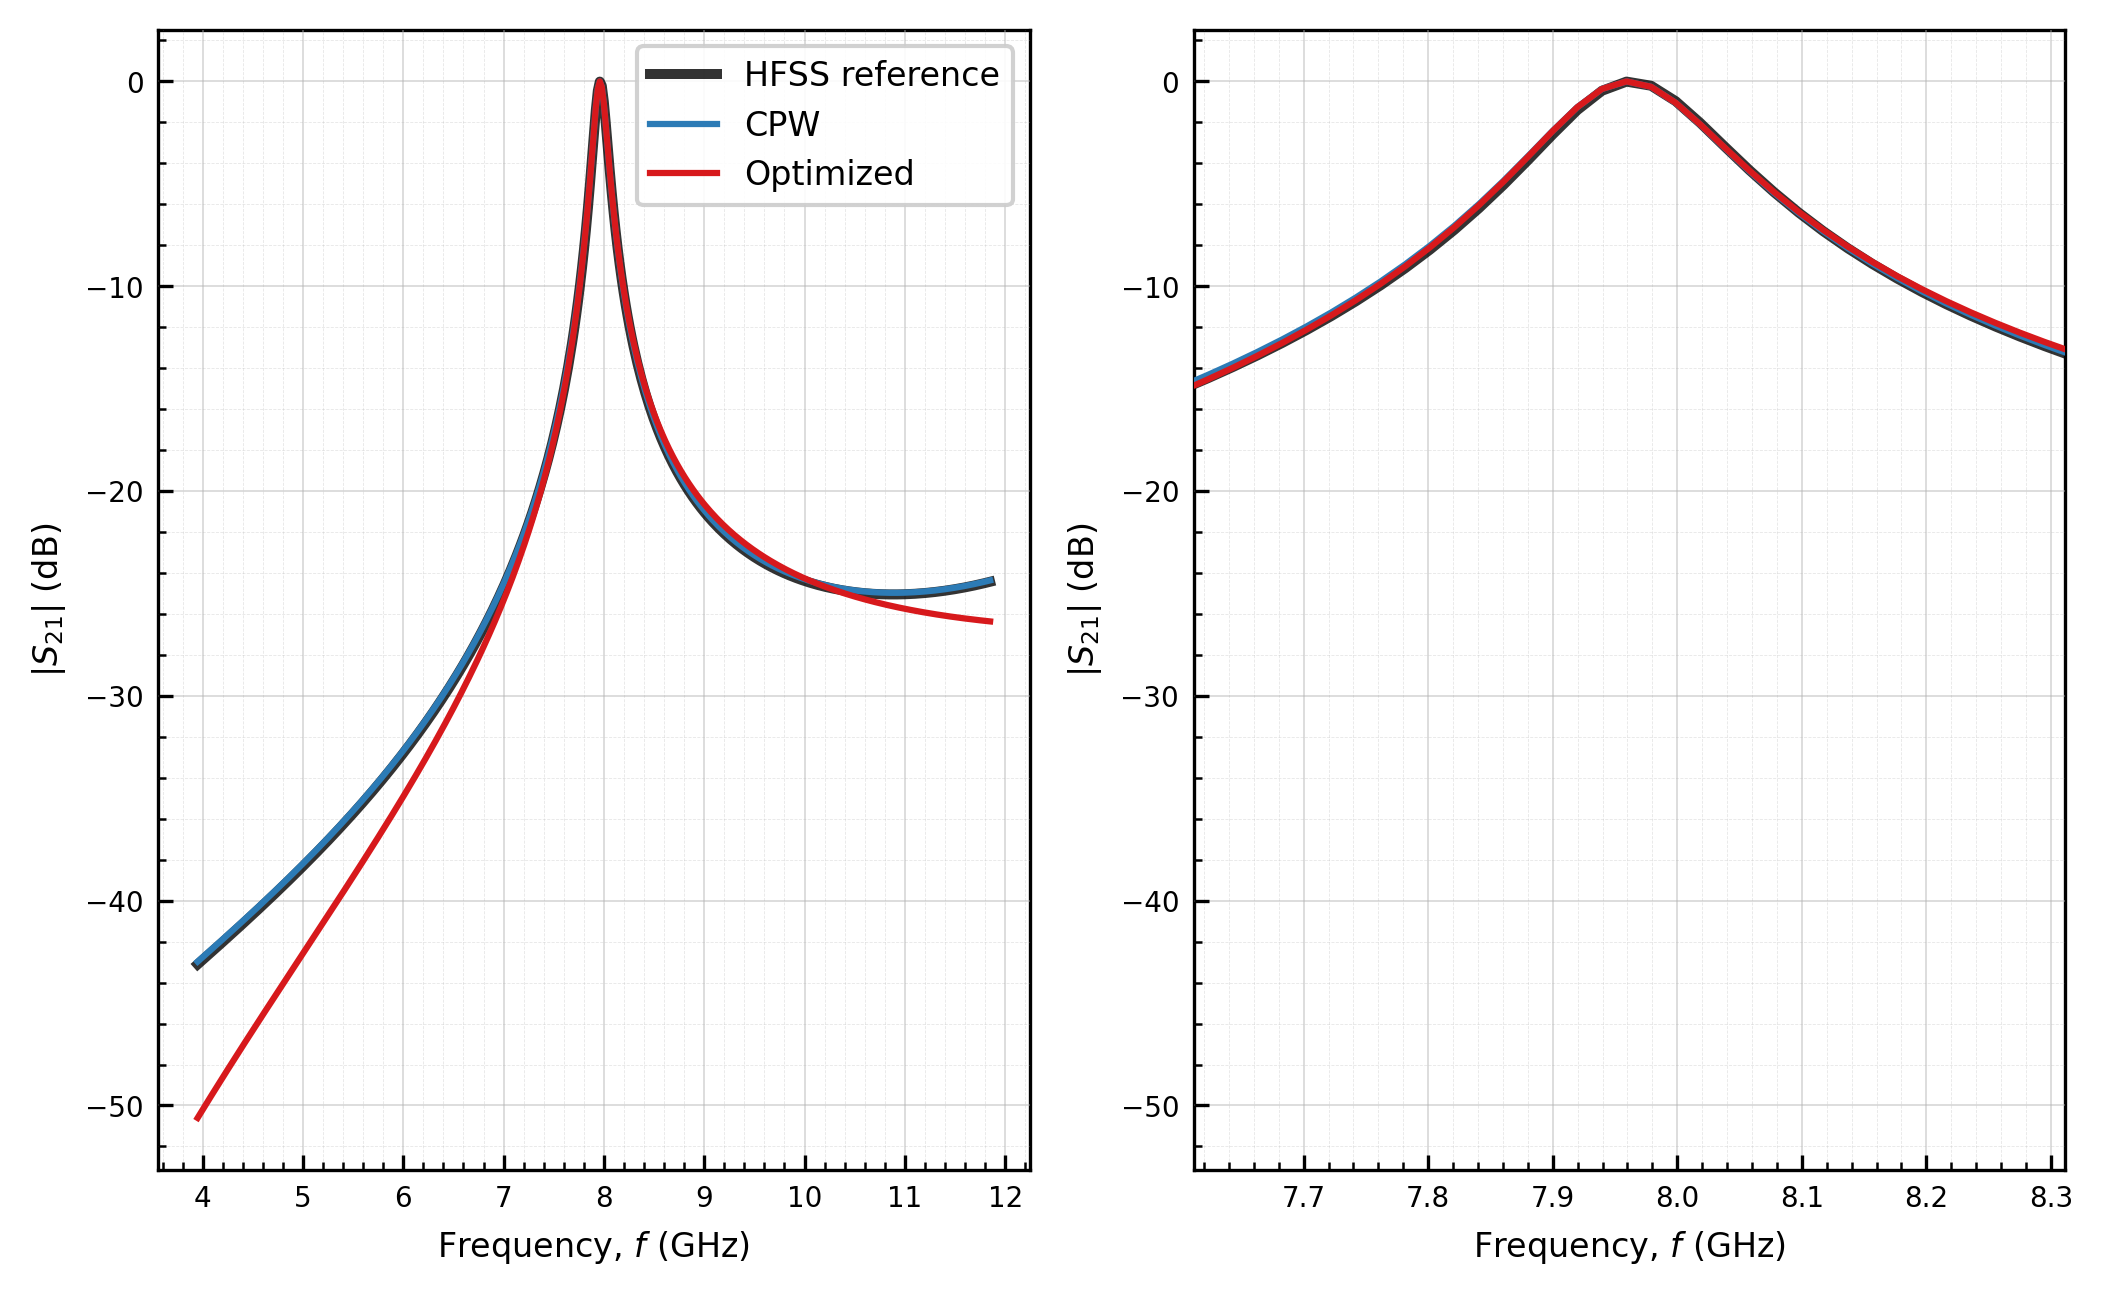

(<Figure size 2117.1x1308.44 with 2 Axes>,
 array([<Axes: xlabel='Frequency, $f$ (GHz)', ylabel='$|S_{21}|$ (dB)'>,
        <Axes: xlabel='Frequency, $f$ (GHz)', ylabel='$|S_{21}|$ (dB)'>],
       dtype=object))

In [8]:
f0_ref, _ = sl.circle_fit_f0_kappa_windowed(ref, 1, 0)
fc = f0_ref / 1e9

sl.plot_transmission(
    {
        "HFSS reference": ref,
        "CPW ground truth": cpw_net,
        "Optimized LOM": net_opt,
    },
    m=1, n=0,
    panels="zoom",
    center=fc,
    half_width=0.35,
    save_path=str(figdir / "s21_overlay.png"),
)


## 5. Quantify the agreement

We now extract $f_0$ and $\kappa$ from each network with
`circle_fit_f0_kappa_windowed`, the variant of the circle fit meant
for data on a fixed frequency grid.

The same extractor is applied to the model networks, which are evaluated on the same
grid, so every row of the table is directly comparable. Typical Touchstone files from a
driven modal simulation can have a grid size of only 401 points, so both $f_0$ and
$\kappa$ are refined to sub-grid accuracy, so that the reported $\Delta f$ reflects the
true model–FEM offset rather than the spacing of the FEM frequency sweep.


In [9]:
win = np.abs(f - f0_ref / 1e9) < 0.5
s21_ref = sl.s_db(ref, 1, 0)

rows = [
    ("HFSS ref",
     "{:.4f}".format(f0_ref / 1e9),
     "{:.3f}".format(sl.circle_fit_f0_kappa_windowed(ref, 1, 0)[1] / 1e6),
     "--", "--"),
]
for name, net in (("CPW", cpw_net), ("Optimized", net_opt)):
    f0, k = sl.circle_fit_f0_kappa_windowed(net, 1, 0)
    dres = np.abs(sl.s_db(net, 1, 0) - s21_ref)[win].max()
    rows.append((
        name,
        "{:.4f}".format(f0 / 1e9),
        "{:.3f}".format(k / 1e6),
        "{:+.3f}".format(100 * (f0 - f0_ref) / f0_ref),
        "{:.3f}".format(dres),
    ))

print(sl.utils.format_comparison_table(
    rows,
    ["model", "f0 (GHz)", "kappa (MHz)", "df (%)", "max|dS21| (dB)"],
))


model      f0 (GHz)  kappa (MHz)  df (%)  max|dS21| (dB)
---------  --------  -----------  ------  --------------
HFSS ref     7.9617      148.097      --              --
CPW          7.9597      149.572  -0.026           0.201
Optimized    7.9593      149.523  -0.030           0.277


Saved: figures/s21_residual.png


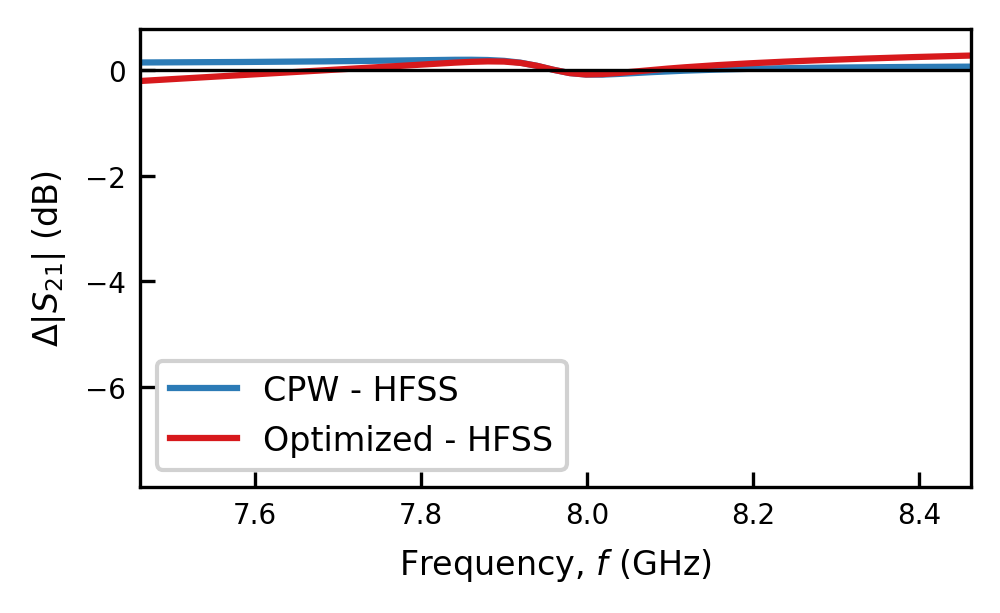

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: xlabel='Frequency, $f$ (GHz)', ylabel='$\\Delta|S_{21}|$ (dB)'>)

In [10]:
sl.plot_s_residual(
    {"CPW - HFSS": cpw_net, "Optimized - HFSS": net_opt},
    ref,
    m=1, n=0,
    xlim=(fc - 0.5, fc + 0.5),
    save_path=str(figdir / "s21_residual.png"),
)


## 6. Stress test: one workflow, five coupling regimes

The walkthrough above used the mildest device. The same recipe to fit LOMs and
extract $f_0$ and $\kappa$ for finite element models applies unchanged to any port loading,
so we can stress the models across various coupling regimes. `results/` ships four more
HFSS exports of the same 7 mm resonator, going from moderately to very strongly coupled.


In [11]:
configs = [
    ("Coupling caps only",  "results/cpw_7mm_hfss.s2p",           50e-15,  50e-15,    0.0),
    ("Grounds included",    "results/cpw_7mm_ctog_hfss.s2p",      50e-15,  50e-15, 40e-15),
    ("Stronger coupling",   "results/cpw_7mm_cc100_hfss.s2p",    100e-15, 100e-15, 40e-15),
    ("Asymmetric coupling", "results/cpw_7mm_cc50_100_hfss.s2p",  50e-15, 100e-15, 40e-15),
    ("Weaker asymmetric",   "results/cpw_7mm_cc20_50_hfss.s2p",   20e-15,  50e-15, 40e-15),
]

summary = []
kappa_MHz = {}    # label -> (HFSS, CPW, Optimized)
for label, path, Cc1, Cc2, Ct in configs:
    ref_i  = rf.Network(path)
    freq_i = ref_i.frequency
    cpw_i  = sl.cpw_resonator_network_2port(freq_i, d, Cc1, Cc2, Ct, Ct,
                                            cpw_params=cpw, Z0=50)
    opt_i  = sl.fit_lom(d, model="optimized", Cc1=Cc1, Cc2=Cc2, Ctog=Ct,
                        cpw_params=cpw, return_model=True)
    net_i  = opt_i.get_network(freq_i, Cc1, Cc2, Z0=50, Ctog1=Ct, Ctog2=Ct)

    f0_r, k_r = sl.circle_fit_f0_kappa_windowed(ref_i, 1, 0)
    f0_c, k_c = sl.circle_fit_f0_kappa_windowed(cpw_i, 1, 0)
    f0_o, k_o = sl.circle_fit_f0_kappa_windowed(net_i, 1, 0)

    kappa_MHz[label] = (k_r / 1e6, k_c / 1e6, k_o / 1e6)
    summary.append((
        label,
        "{:.4f}".format(f0_r / 1e9),
        "{:.1f}".format(k_r / 1e6),
        "{:+.3f}".format(100 * (f0_c - f0_r) / f0_r),
        "{:+.2f}".format(100 * (k_c - k_r) / k_r),
        "{:+.3f}".format(100 * (f0_o - f0_r) / f0_r),
        "{:+.2f}".format(100 * (k_o - k_r) / k_r),
    ))

print(sl.utils.format_comparison_table(
    summary,
    ["config", "f0 (GHz)", "kappa (MHz)",
     "df CPW (%)", "dk CPW (%)", "df Opt (%)", "dk Opt (%)"],
))


config               f0 (GHz)  kappa (MHz)  df CPW (%)  dk CPW (%)  df Opt (%)  dk Opt (%)
-------------------  --------  -----------  ----------  ----------  ----------  ----------
Coupling caps only     7.9617        148.1      -0.026       +1.00      -0.030       +1.02
Grounds included       7.5372        123.8      -0.172       +1.72      -0.175       +1.71
Stronger coupling      7.1166        370.9      -0.488       +1.43      -0.532       +1.03
Asymmetric coupling    7.3231        255.4      -0.332       +2.07      -0.329       +1.06
Weaker asymmetric      7.6892         86.7      -0.133       -1.78      -0.133       -1.98


We can also plot a parity plot of the linewidth values for the FEMs to see how well
the models track the HFSS reference across all five coupling regimes.


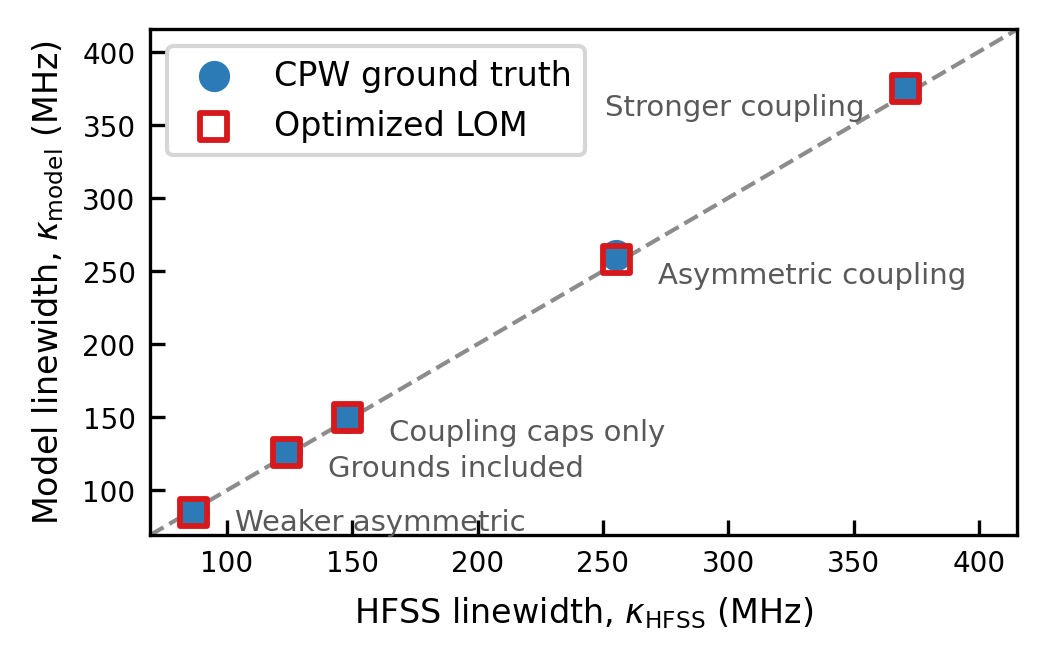

In [12]:
fig, ax = plt.subplots(
    figsize=(sl.FIGURE_WIDTH_1COL, sl.FIGURE_HEIGHT_1COL_GR), layout="constrained"
)

k_r = np.array([kappa_MHz[label][0] for label, *_ in configs])
k_c = np.array([kappa_MHz[label][1] for label, *_ in configs])
k_o = np.array([kappa_MHz[label][2] for label, *_ in configs])

lim = (0.8 * k_r.min(), 1.12 * k_r.max())
ax.plot(lim, lim, ls="--", lw=1.0, color="0.55", zorder=1)
ax.scatter(k_r, k_c, s=42, color=sl.MODEL_COLORS["cpw"],
           label="CPW ground truth", zorder=3)
ax.scatter(k_r, k_o, s=42, marker="s", facecolors="none",
           edgecolors=sl.MODEL_COLORS["optimized"], linewidths=1.4,
           label="Optimized LOM", zorder=3)
# Label beside each point: the half-plane off the diagonal is empty, so text
# placed to the right (or left, near the right edge) never hits data.
for x, (label, *_rest) in zip(k_r, configs):
    right = x < 0.75 * lim[1]
    ax.annotate(label, (x, x),
                xytext=(10, -3) if right else (-10, -3),
                textcoords="offset points", fontsize=7, color="0.35",
                ha="left" if right else "right", va="center")

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel(sl.axis_label("HFSS linewidth", r"\kappa_\mathrm{HFSS}", "MHz"))
ax.set_ylabel(sl.axis_label("Model linewidth", r"\kappa_\mathrm{model}", "MHz"))
ax.legend(loc="upper left")

fig.savefig(figdir / "kappa_parity.png", dpi=200)


## Notes

- Across all five coupling regimes both models land on the HFSS resonance to
  within $0.5\%$ in $f_0$ and $\sim 2\%$ in $\kappa$ — while $\kappa$ itself
  varies by more than $4\times$.
- **To use your own data:** drop your `.s2p` in `results/`, point
  `rf.Network(...)` at it, and set `d`, `Cc`, `Ctog`, and `CPWParams` to match the
  simulated geometry. If your port ordering differs, adjust the `(m, n)` indices
  passed to `circle_fit_f0_kappa_windowed` and the `s[:, 1, 0]` slice accordingly.
